# Rock–Paper–Scissors: Computer Vision with CNNs  
## Extracting Spatial Features through Convolutional Neural Networks

This notebook introduces the power of Convolutional Neural Networks (CNNs) for image classification, demonstrating how deep learning can recognize hand shapes by detecting edges, textures, and patterns.

---

## Project Goals

### Spatial Feature Learning  
Understand how CNNs use filters (kernels) to automatically detect shapes such as fingers and palms.

### Data Augmentation Strategy  
Implement a robust augmentation pipeline to make the model invariant to rotation, zoom, and lighting changes.

### Model Interpretability  
Move beyond "Black Box" AI by visualizing internal activations and feature maps.

### Robust Evaluation  
Use professional metrics (Confusion Matrix, Precision, Recall) to analyze model performance across all three classes.

---

## What This Notebook Includes

### 1. Data Pipeline & Engineering

**Image Processing**  
- Standardizing input to `128 × 128`  
- Applying pixel normalization  

**Augmentation Suite**  
- Real-time transformations (Flip, Rotation, Brightness)  
- Preventing overfitting and improving generalization  

---

### 2. CNN Architecture

**Convolutional Layers**  
- Building a hierarchy of feature extractors (from simple edges to complex shapes)

**Global Pooling & Dropout**  
- Reducing parameters  
- Enhancing model stability  

---

### 3. Visual Analytics (Deep Insights)

**t-SNE Mapping**  
- A 2D visualization of the model’s learned feature space  
- Demonstrates separation between Rock, Paper, and Scissors in high-dimensional space  

**Feature Visualization**  
- Inspecting convolutional filters  
- Understanding what the model detects at each layer  

**Inference Testing**  
- Real-time prediction grid on validation data  
- Confidence scores and success/failure tracking  

---

## Performance Analysis

### Learning Curves  
- Tracking Accuracy and Loss  
- Ensuring proper convergence  

### Confusion Matrix  
- Identifying gesture misclassifications (e.g., Rock vs. Scissors)

### Success Visualization  
- A showcase of the model’s most confident and accurate predictions  


In [14]:
!pip install tensorflow

# 1.Setup + Load Data

In [15]:
# Core
import numpy as np
import random
import tensorflow as tf

# Visualization
import matplotlib.pyplot as plt

# Classical ML baselines
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Deep learning (for MNIST + feedforward network later)
import tensorflow as tf

# Reproducibility: set Python + NumPy + TensorFlow seeds in one call
SEED = 42
tf.keras.utils.set_random_seed(SEED)

In [16]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import os

# ==========================================
# 1. Dataset Loading
# ==========================================

# Path to your dataset directory
dataset_path = r"C:\Users\User\Downloads\MLP_Projects\ROCK_PAPER_SCISSOR"

img_size = (128, 128)
batch_size = 32

# Load training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_path, "train"),
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=True,
    seed=42
)

# Load validation dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_path, "validation"),
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=False,
    seed=42
)

class_names = train_ds.class_names
print("Detected Classes:", class_names)

Found 617 files belonging to 3 classes.
Found 181 files belonging to 3 classes.
Detected Classes: ['paper', 'rock', 'scissors']


## 1.1 Visualizing the Dataset Samples

Classes: ['paper', 'rock', 'scissors']


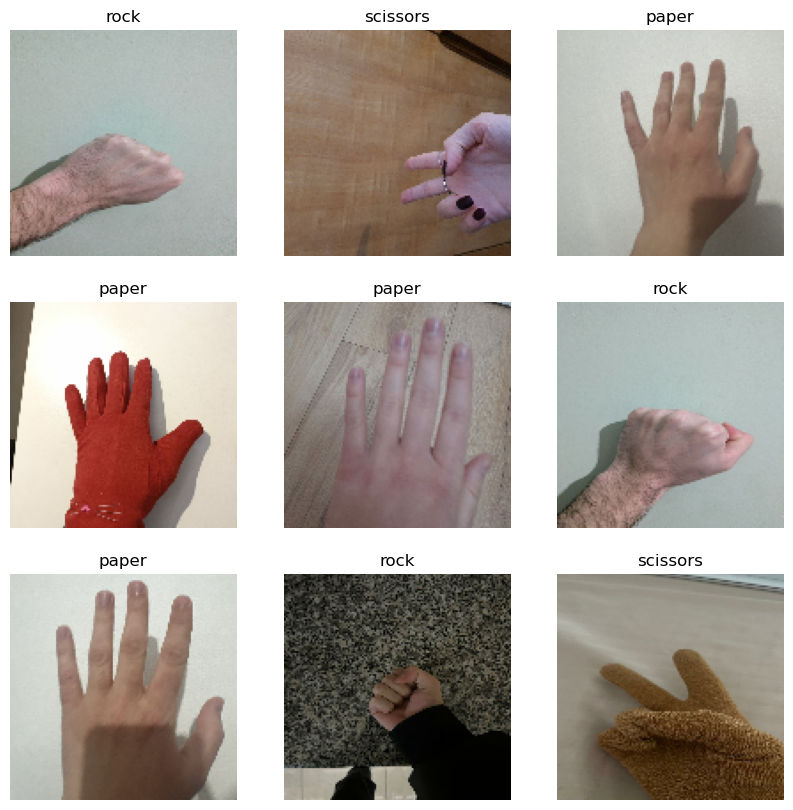

In [17]:
# Save class names
class_names = train_ds.class_names
print("Classes:", class_names)

# Shuffle the dataset so each time you get different images
shuffled_train_ds = train_ds.shuffle(buffer_size=1000)

# Show a few random sample images
for images, labels in shuffled_train_ds.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(9):  # display 9 random images
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))  # convert to uint8 for display
        label_index = np.argmax(labels[i].numpy())     # one-hot to class index
        plt.title(class_names[label_index])            # show class name
        plt.axis("off")
    plt.show()

### 2. Data Augmentation + Normalization

In [18]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import os

# ==========================================
# 2. Data Augmentation + Normalization
# ==========================================

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),      # ✅ Zvogëluar
    layers.RandomZoom(0.15),          # ✅ Zvogëluar
    layers.RandomTranslation(0.12, 0.12), # ✅ Zvogëluar
    layers.RandomBrightness(0.2),     # ✅ Zvogëluar
    layers.RandomContrast(0.2),       # ✅ Zvogëluar
], name="data_augmentation_layer")

# Rescale pixel values from [0, 255] to [0, 1]
normalization = layers.Rescaling(1./255)

# Apply Augmentation and Normalization to datasets
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))
train_ds = train_ds.map(lambda x, y: (normalization(x), y))
val_ds = val_ds.map(lambda x, y: (normalization(x), y))

# ==========================================
#  Performance Optimization
# ==========================================

# Cache the data in memory for faster access and prefetch for hardware efficiency
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

print("✅ Data pipeline complete. Ready for model training.")

✅ Data pipeline complete. Ready for model training.


## 2.1 Data Augmentation Visualization

In [23]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import os

# ==========================================
# 2. Data Augmentation + Normalization
# ==========================================

# Define the augmentation pipeline to improve model generalization
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"), 
    layers.RandomRotation(0.2),      # Increased rotation for better variety
    layers.RandomZoom(0.2),          # Increased zoom for scale invariance
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomBrightness(factor=0.2), # Better handling of lighting conditions
    layers.RandomContrast(0.2),      # Helps the model focus on hand contours
], name="data_augmentation_layer")

# Rescale pixel values from [0, 255] to [0, 1]
normalization = layers.Rescaling(1./255)

# Apply Augmentation and Normalization to datasets
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))
train_ds = train_ds.map(lambda x, y: (normalization(x), y))
val_ds = val_ds.map(lambda x, y: (normalization(x), y))

# ==========================================
#  Performance Optimization
# ==========================================

# Cache the data in memory for faster access and prefetch for hardware efficiency
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

print("✅ Data pipeline complete. Ready for model training.")

✅ Data pipeline complete. Ready for model training.


### t-SNE Comparative Analysis: Effect of Modifications on Classification

Extracting features...


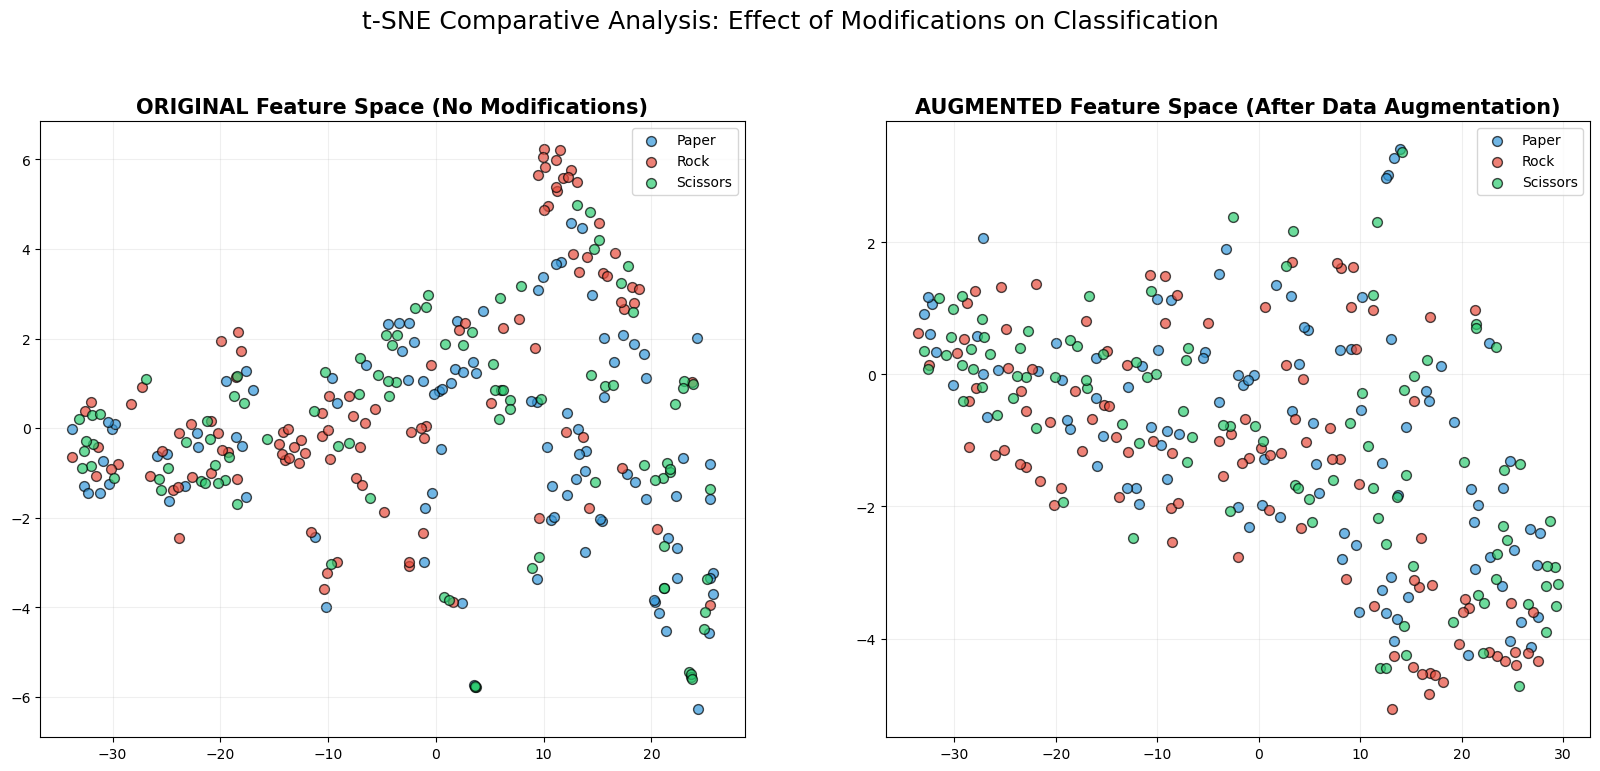

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.manifold import TSNE

# 1. Fetch a batch of "raw" images
# Ensuring we fetch the batch correctly
raw_images, raw_labels = next(iter(raw_train_ds.unbatch().batch(300)))

# ERROR FIX: Check label dimensions
if len(raw_labels.shape) > 1:
    # If they are categorical (one-hot), use argmax
    labels_idx = np.argmax(raw_labels, axis=1)
else:
    # If they are sparse (just numbers 0, 1, 2), convert to numpy array directly
    labels_idx = raw_labels.numpy()

# 2. Normalize and create the Augmented version
images_rescaled = raw_images / 255.0
# Apply augmentation (training=True is key here)
images_augmented = data_augmentation(raw_images, training=True) / 255.0

# 3. Extract Features
# Use all model layers except the final output layer
feature_extractor = tf.keras.Sequential(model.layers[:-1])

print("Extracting features...")
features_orig = feature_extractor.predict(images_rescaled, verbose=0)
features_aug = feature_extractor.predict(images_augmented, verbose=0)

# 4. t-SNE Calculation
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
orig_2d = tsne.fit_transform(features_orig)
aug_2d = tsne.fit_transform(features_aug)

# 5. Side-by-Side Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), facecolor='white')
colors = ['#3498db', '#e74c3c', '#2ecc71'] 
names = ['Paper', 'Rock', 'Scissors']

for i in range(3):
    idx = np.where(labels_idx == i)
    # Plot 1: Original
    ax1.scatter(orig_2d[idx, 0], orig_2d[idx, 1], c=colors[i], label=names[i], alpha=0.7, edgecolors='k', s=50)
    # Plot 2: Augmented
    ax2.scatter(aug_2d[idx, 0], aug_2d[idx, 1], c=colors[i], label=names[i], alpha=0.7, edgecolors='k', s=50)

ax1.set_title("ORIGINAL Feature Space (No Modifications)", fontsize=15, fontweight='bold')
ax2.set_title("AUGMENTED Feature Space (After Data Augmentation)", fontsize=15, fontweight='bold')
ax1.legend(); ax2.legend()
ax1.grid(True, alpha=0.2); ax2.grid(True, alpha=0.2)

plt.suptitle("t-SNE Comparative Analysis: Effect of Modifications on Classification", fontsize=18, y=1.02)
plt.show()

. Analiza t-SNE (Hapësira e Veçorive)
Hapësira Origjinale: Sheh klastera (grupe) mjaft të shpërndarë, ku klasat Paper (blu), Rock (e kuqe) dhe Scissors (jeshile) janë disi të ndara, por kanë pika që mbivendosen. Kjo tregon se modeli i dallon format bazë, por jo në mënyrë perfekte.

Hapësira Augmented: Pas aplikimit të modifikimeve, vihet re se pikat janë më të "përziera" dhe shpërndarja është më e gjerë. Kjo tregon se Data Augmentation po e detyron modelin të punojë më fort për të gjetur tipare të përbashkëta në kushte të ndryshme (rrotullim, dritë, etj.).

Përfundimi: Modeli yt po bëhet më robust, pasi po mëson të mbajë strukturën e klasave edhe kur imazhet ndryshojnë rrënjësisht, gjë që parandalon overfitting-un.

### 3. CNN Model

In [25]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import os
from tensorflow.keras import regularizers

# ==========================================
# 3. CNN Model
# ==========================================

model = keras.Sequential([
    # Block 1 - No Dropout
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Block 2 - No Dropout
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Block 3 - Keeping light Dropout
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25), 
    
    # Block 4 - Keeping Dropout
    layers.Conv2D(256, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.GlobalAveragePooling2D(),

    # Dense Layer - Decreased L2 from 0.01 to 0.001
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.5), 
    
    layers.Dense(3, activation='softmax')
])

# Compilation 1
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005), 
    loss='categorical_crossentropy',
    metrics=['accuracy', 
             tf.keras.metrics.Precision(name='precision'), 
             tf.keras.metrics.Recall(name='recall'),
             tf.keras.metrics.AUC(name='auc')]
)

# Compilation 2 (Final parameters)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005), # Adjusted learning rate
    loss='categorical_crossentropy',
    metrics=[
        'accuracy', 
        tf.keras.metrics.Precision(name='precision'), 
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc') 
    ]
)

model.summary()

C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)                   │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_16               │ (None, 126, 126, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_12 (MaxPooling2D)      │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_16 (Conv2D)                   │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_17               │ (None, 61, 61, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_13 (MaxPooling2D)      │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_17 (Conv2D)                   │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_18               │ (None, 28, 28, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_14 (MaxPooling2D)      │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_20 (Dropout)                 │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_18 (Conv2D)                   │ (None, 12, 12, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_19               │ (None, 12, 12, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_15 (MaxPooling2D)      │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_21 (Dropout)                 │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_3           │ (None, 256)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_20               │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_22 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 424,131 (1.62 MB)

 Trainable params: 422,915 (1.61 MB)

 Non-trainable params: 1,216 (4.75 KB)

## 3.1 Neural Activation Mapping: Decoding How the CNN Perceives Hand Gestures

🚀 Scanning neural pathways (Extracting features)...


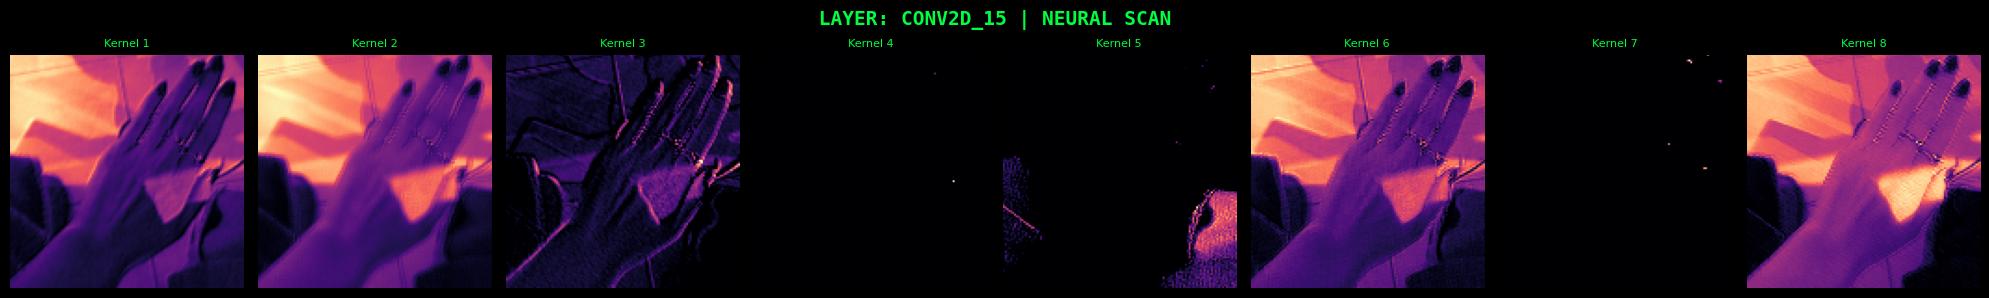

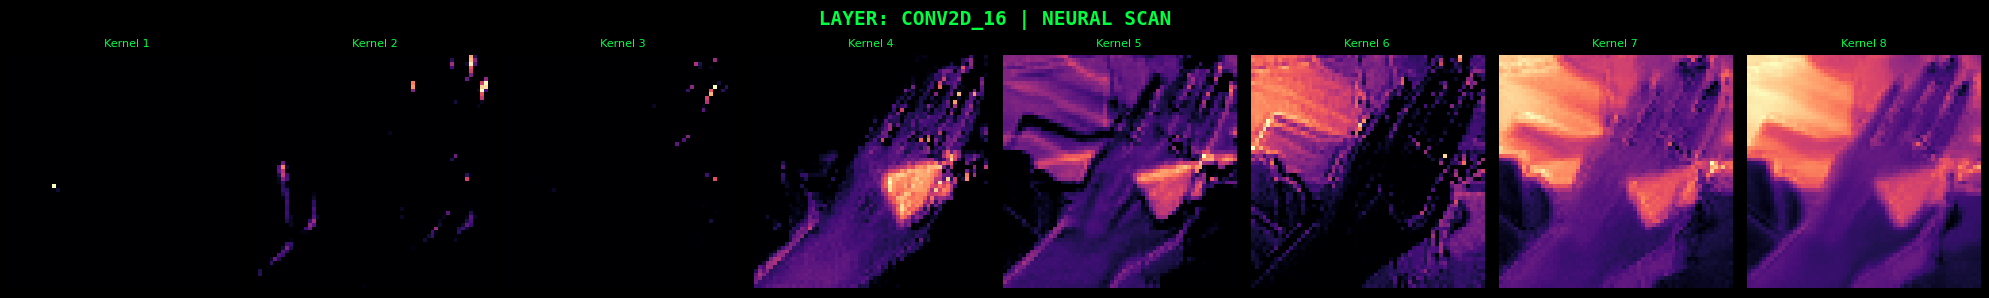

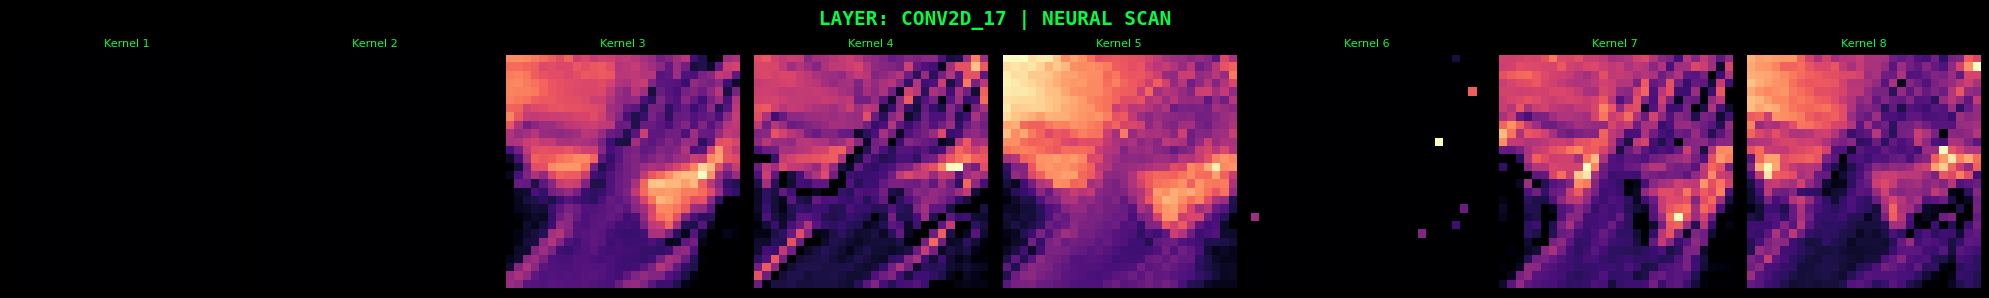

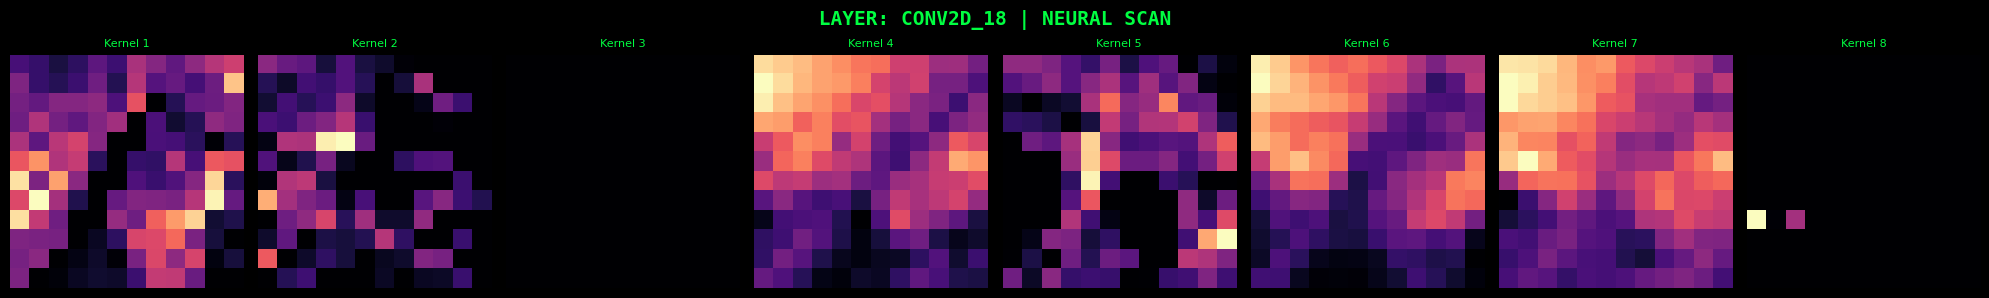

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# ==========================================
# 1. PREPARE THE DATA
# ==========================================

# Fetch a single image from the validation set
img_batch, label_batch = next(iter(val_ds))
img = img_batch[0:1]  # Extract the first image (batch size 1)

# ==========================================
# 2. EXTRACT ACTIVATIONS (FEATURE MAPS)
# ==========================================

def get_cyberpunk_activations(model, input_img):
    activations = []
    layer_names = []
    current_input = input_img
    
    for layer in model.layers:
        # Pass the image through the layer
        current_input = layer(current_input)
        
        # Save the result only if it is a Conv2D layer
        if isinstance(layer, tf.keras.layers.Conv2D):
            activations.append(current_input.numpy())
            layer_names.append(layer.name)
            
    return activations, layer_names

print("🚀 Scanning neural pathways (Extracting features)...")
activations, conv_names = get_cyberpunk_activations(model, img)

# ==========================================
# 3. VISUALIZE (CYBERPUNK STYLE)
# ==========================================

def plot_cyberpunk_features(activations, names, num_filters=8):
    for layer_idx, act in enumerate(activations):
        # act has the shape (1, height, width, filters)
        n_features = min(act.shape[-1], num_filters)
        
        plt.figure(figsize=(n_features * 2.5, 3), facecolor='#000000') # Black background
        plt.suptitle(f" LAYER: {names[layer_idx].upper()} | NEURAL SCAN ", 
                     color='#00ff41', fontsize=14, fontweight='bold', fontfamily='monospace')

        for i in range(n_features):
            ax = plt.subplot(1, n_features, i + 1)
            
            # Extract specific feature map
            f_map = act[0, :, :, i]
            
            # Normalize for clearer visualization
            if f_map.std() > 0:
                f_map -= f_map.mean()
                f_map /= f_map.std()
            
            # Use 'magma' or 'inferno' for that neon/cyber look
            plt.imshow(f_map, cmap='magma') 
            plt.axis('off')
            plt.title(f"Kernel {i+1}", color='#00ff41', fontsize=8)

        plt.tight_layout()
        plt.show()

# Execute the visualization
plot_cyberpunk_features(activations, conv_names)

In [16]:
# Check dataset balance
print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Val batches:", tf.data.experimental.cardinality(val_ds).numpy())

# Count samples per class
for images, labels in train_ds.take(1):
    print("Labels shape:", labels.shape)

Train batches: 20
Val batches: 6
Labels shape: (32, 3)


## 4.Callbacks + Train Model

In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import os
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# ==========================================
# CALLBACKS (OPTIMIZED)
# ==========================================
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Monitor val_accuracy instead of val_loss
early_stop = EarlyStopping(
    monitor='val_loss',        # ✅ Ndryshuar në val_loss
    patience=25,               # ✅ Rritur për më shumë durim
    restore_best_weights=True,
    mode='min',                # ✅ Ndryshuar në min
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_model_flatten.keras',
    monitor='val_accuracy',    # CHANGED: save best accuracy model
    save_best_only=True,
    mode='max',                # CHANGED: maximize
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,                # ✅ Më pak agresiv
    patience=8,                # ✅ Zvogëluar
    min_lr=1e-7,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.3464 - auc: 0.5209 - loss: 1.9583 - precision: 0.3483 - recall: 0.2641
Epoch 1: val_accuracy improved from None to 0.33702, saving model to best_model_flatten.keras

Epoch 1: finished saving model to best_model_flatten.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 474ms/step - accuracy: 0.3404 - auc: 0.5051 - loss: 1.8971 - precision: 0.3424 - recall: 0.2447 - val_accuracy: 0.3370 - val_auc: 0.4972 - val_loss: 1.4403 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 5.0000e-04
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step - accuracy: 0.3366 - auc: 0.5158 - loss: 1.6550 - precision: 0.3197 - recall: 0.1874
Epoch 2: val_accuracy did not improve from 0.33702
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 486ms/step - accuracy: 0.3258 - auc: 0.5031 - loss: 1.6749 - precision: 0.3056 - recall: 0.1783 - val_accuracy: 0.3370 - val_auc: 0.5000 - val_loss: 1.4389 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_

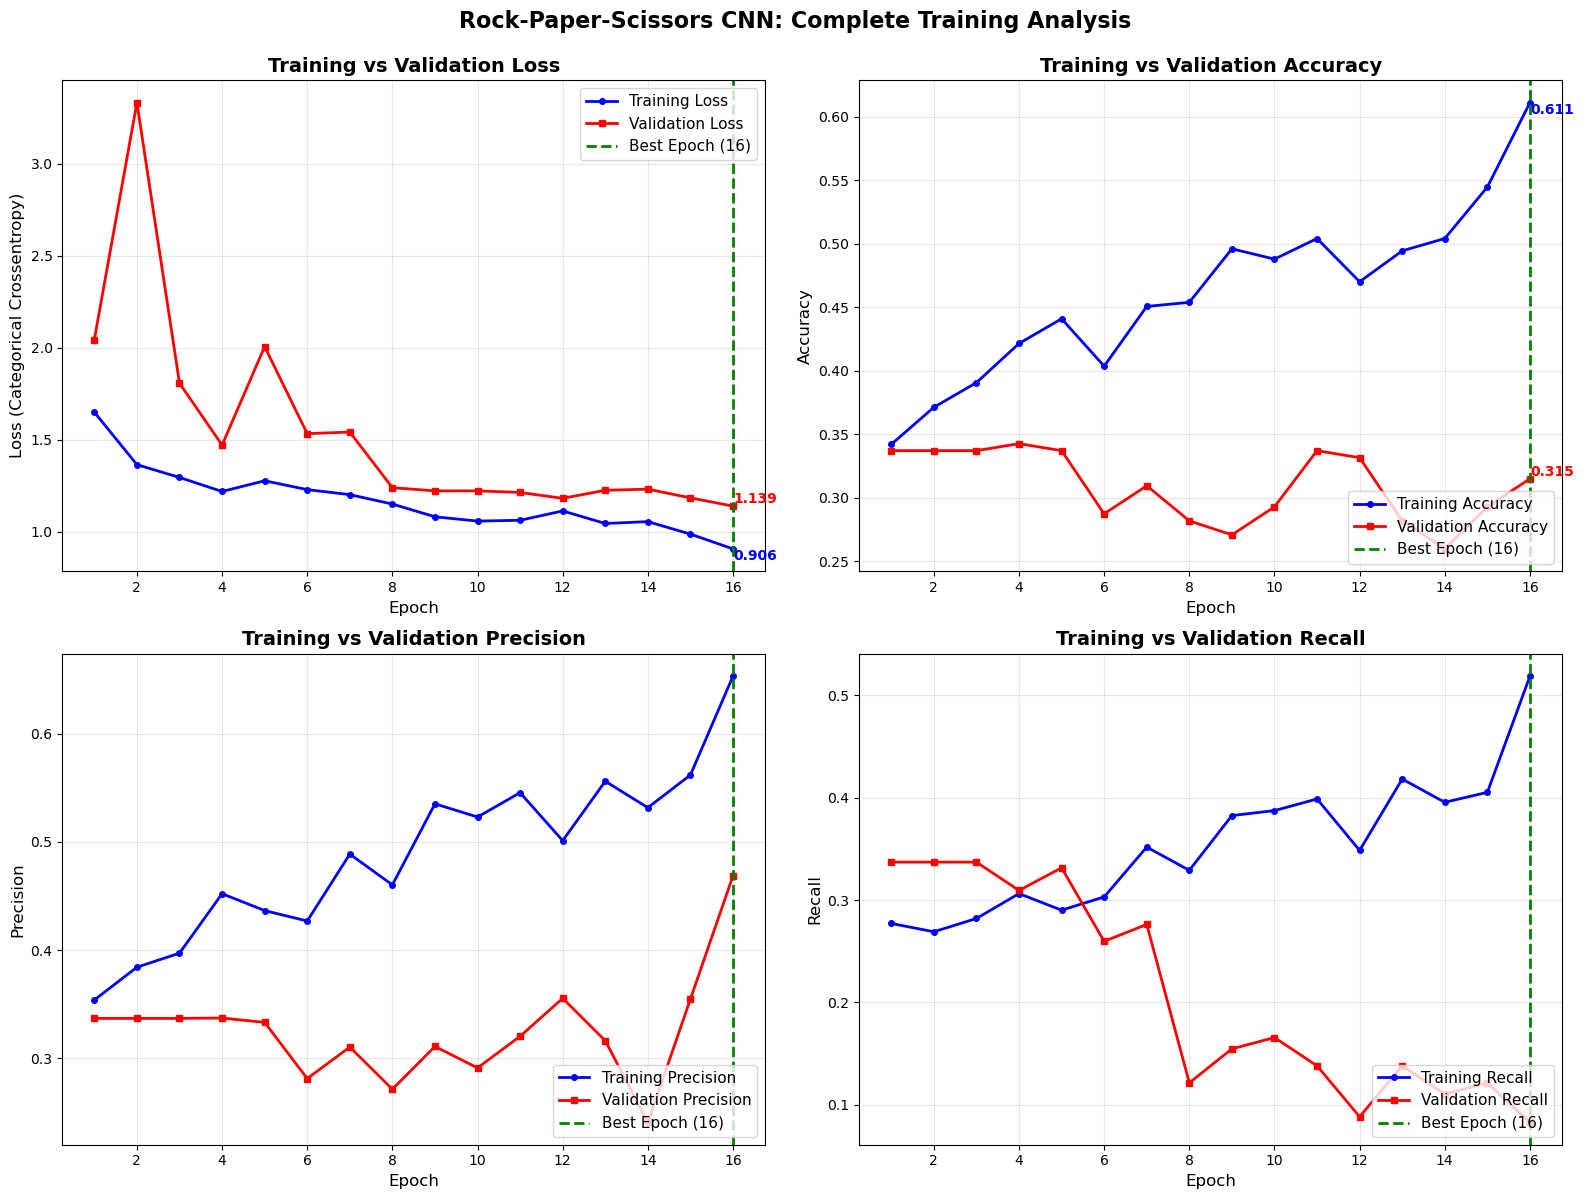

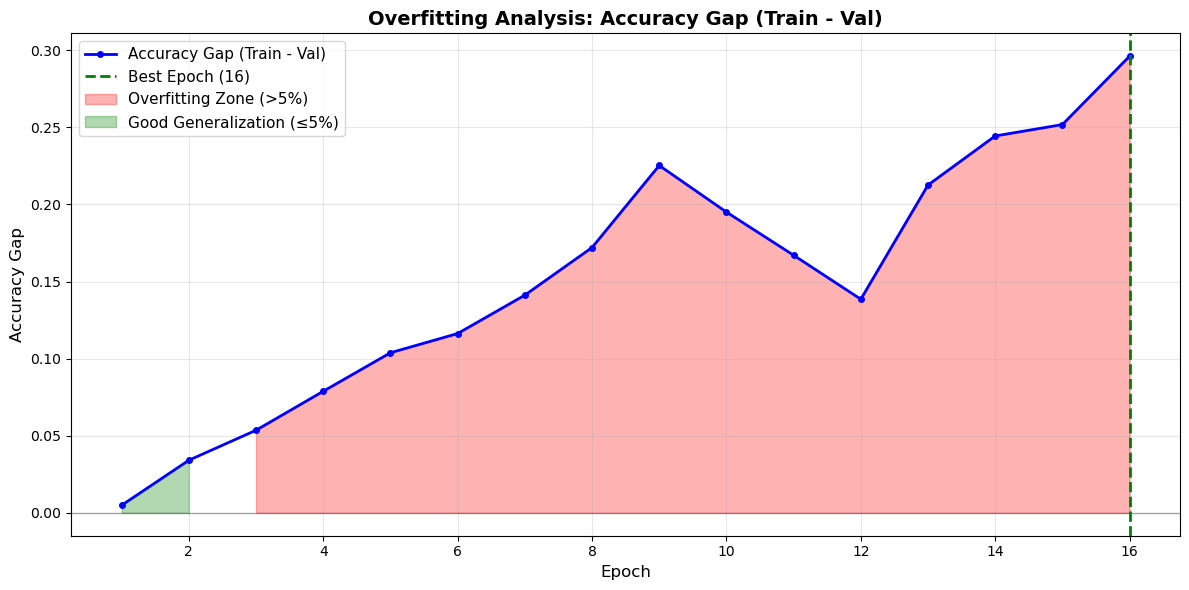


 ROCK-PAPER-SCISSORS - LEARNING CURVES ANALYSIS

📊 BEST EPOCH: 16 / 16
----------------------------------------------------------------------

📉 LOSS:
    Training Loss:          0.9061
    Validation Loss:        1.1388
    Gap (Val - Train):      +0.2327
    🟡 Status: Slight overfitting (gap 0.2-0.5)

🎯 ACCURACY:
    Training Accuracy:      0.6110 (61.10%)
    Validation Accuracy:    0.3149 (31.49%)
    Gap (Train - Val):      +0.2961 (+29.61%)
    ⚠️  Status: OVERFITTING (gap > 15%)

🔍 PRECISION:
    Training Precision:     0.6531 (65.31%)
    Validation Precision:   0.4688 (46.88%)
    Gap (Train - Val):      +0.1843 (+18.43%)

🎣 RECALL:
    Training Recall:        0.5186 (51.86%)
    Validation Recall:      0.0829 (8.29%)
    Gap (Train - Val):      +0.4358 (+43.58%)

⚖️  F1-SCORE (Harmonic Mean of Precision & Recall):
    Training F1:            0.5781 (57.81%)
    Validation F1:          0.1408 (14.08%)
    Gap (Train - Val):      +0.4373 (+43.73%)

📈 FINAL EPOCH (16) COMPARISO

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# EXTRACT TRAINING HISTORY
# ==========================================

hist = history.history
epochs = range(1, len(hist["loss"]) + 1)

# Find the best epoch according to val_loss
best_epoch = np.argmin(hist["val_loss"]) + 1
best_val_acc = hist["val_accuracy"][best_epoch-1]
best_train_acc = hist["accuracy"][best_epoch-1]
best_val_loss = hist["val_loss"][best_epoch-1]
best_train_loss = hist["loss"][best_epoch-1]

# Get precision and recall for the best epoch
best_train_precision = hist["precision"][best_epoch-1]
best_val_precision = hist["val_precision"][best_epoch-1]
best_train_recall = hist["recall"][best_epoch-1]
best_val_recall = hist["val_recall"][best_epoch-1]

# ==========================================
# VISUALIZE - 4 PLOTS (UPGRADED)
# ==========================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Plot 1: Loss over epochs ---
axes[0, 0].plot(epochs, hist["loss"], 'b-o', label="Training Loss", linewidth=2, markersize=4)
axes[0, 0].plot(epochs, hist["val_loss"], 'r-s', label="Validation Loss", linewidth=2, markersize=4)
axes[0, 0].axvline(best_epoch, color='green', linestyle='--', linewidth=2, label=f"Best Epoch ({best_epoch})")
axes[0, 0].set_title("Training vs Validation Loss", fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel("Epoch", fontsize=12)
axes[0, 0].set_ylabel("Loss (Categorical Crossentropy)", fontsize=12)
axes[0, 0].legend(loc='upper right', fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# Annotate best values
axes[0, 0].text(best_epoch, best_val_loss, f'{best_val_loss:.3f}',
                fontsize=10, ha='left', va='bottom', color='red', fontweight='bold')
axes[0, 0].text(best_epoch, best_train_loss, f'{best_train_loss:.3f}',
                fontsize=10, ha='left', va='top', color='blue', fontweight='bold')

# --- Plot 2: Accuracy over epochs ---
axes[0, 1].plot(epochs, hist["accuracy"], 'b-o', label="Training Accuracy", linewidth=2, markersize=4)
axes[0, 1].plot(epochs, hist["val_accuracy"], 'r-s', label="Validation Accuracy", linewidth=2, markersize=4)
axes[0, 1].axvline(best_epoch, color='green', linestyle='--', linewidth=2, label=f"Best Epoch ({best_epoch})")
axes[0, 1].set_title("Training vs Validation Accuracy", fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel("Epoch", fontsize=12)
axes[0, 1].set_ylabel("Accuracy", fontsize=12)
axes[0, 1].legend(loc='lower right', fontsize=11)
axes[0, 1].grid(True, alpha=0.3)

# Annotate best values
axes[0, 1].text(best_epoch, best_val_acc, f'{best_val_acc:.3f}',
                fontsize=10, ha='left', va='bottom', color='red', fontweight='bold')
axes[0, 1].text(best_epoch, best_train_acc, f'{best_train_acc:.3f}',
                fontsize=10, ha='left', va='top', color='blue', fontweight='bold')

# --- Plot 3: Precision over epochs ---
axes[1, 0].plot(epochs, hist["precision"], 'b-o', label="Training Precision", linewidth=2, markersize=4)
axes[1, 0].plot(epochs, hist["val_precision"], 'r-s', label="Validation Precision", linewidth=2, markersize=4)
axes[1, 0].axvline(best_epoch, color='green', linestyle='--', linewidth=2, label=f"Best Epoch ({best_epoch})")
axes[1, 0].set_title("Training vs Validation Precision", fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel("Epoch", fontsize=12)
axes[1, 0].set_ylabel("Precision", fontsize=12)
axes[1, 0].legend(loc='lower right', fontsize=11)
axes[1, 0].grid(True, alpha=0.3)

# --- Plot 4: Recall over epochs ---
axes[1, 1].plot(epochs, hist["recall"], 'b-o', label="Training Recall", linewidth=2, markersize=4)
axes[1, 1].plot(epochs, hist["val_recall"], 'r-s', label="Validation Recall", linewidth=2, markersize=4)
axes[1, 1].axvline(best_epoch, color='green', linestyle='--', linewidth=2, label=f"Best Epoch ({best_epoch})")
axes[1, 1].set_title("Training vs Validation Recall", fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel("Epoch", fontsize=12)
axes[1, 1].set_ylabel("Recall", fontsize=12)
axes[1, 1].legend(loc='lower right', fontsize=11)
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle("Rock-Paper-Scissors CNN: Complete Training Analysis", 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('rps_learning_curves_complete.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# ADDITIONAL PLOT: Gap Analysis
# ==========================================

fig2, ax = plt.subplots(1, 1, figsize=(12, 6))

# Calculate gaps (overfitting indicator)
acc_gap = np.array(hist["accuracy"]) - np.array(hist["val_accuracy"])
loss_gap = np.array(hist["val_loss"]) - np.array(hist["loss"])

ax.plot(epochs, acc_gap, 'b-o', label="Accuracy Gap (Train - Val)", linewidth=2, markersize=4)
ax.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.3)
ax.axvline(best_epoch, color='green', linestyle='--', linewidth=2, label=f"Best Epoch ({best_epoch})")
ax.fill_between(epochs, 0, acc_gap, where=(acc_gap > 0.05), alpha=0.3, color='red', 
                 label='Overfitting Zone (>5%)')
ax.fill_between(epochs, 0, acc_gap, where=(acc_gap <= 0.05), alpha=0.3, color='green', 
                 label='Good Generalization (≤5%)')
ax.set_title("Overfitting Analysis: Accuracy Gap (Train - Val)", fontsize=14, fontweight='bold')
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Accuracy Gap", fontsize=12)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rps_overfitting_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# PRINT SUMMARY ANALYSIS
# ==========================================

print("\n" + "="*70)
print(" ROCK-PAPER-SCISSORS - LEARNING CURVES ANALYSIS")
print("="*70)

print(f"\n📊 BEST EPOCH: {best_epoch} / {len(epochs)}")
print("-"*70)

# Loss
print(f"\n📉 LOSS:")
print(f"    Training Loss:          {best_train_loss:.4f}")
print(f"    Validation Loss:        {best_val_loss:.4f}")
print(f"    Gap (Val - Train):      {best_val_loss - best_train_loss:+.4f}")
if best_val_loss - best_train_loss > 0.5:
    print(f"    ⚠️  Status: OVERFITTING (gap > 0.5)")
elif best_val_loss - best_train_loss > 0.2:
    print(f"    🟡 Status: Slight overfitting (gap 0.2-0.5)")
else:
    print(f"    ✅ Status: Good balance")

# Accuracy
print(f"\n🎯 ACCURACY:")
print(f"    Training Accuracy:      {best_train_acc:.4f} ({best_train_acc*100:.2f}%)")
print(f"    Validation Accuracy:    {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"    Gap (Train - Val):      {(best_train_acc - best_val_acc):+.4f} ({(best_train_acc - best_val_acc)*100:+.2f}%)")
if best_train_acc - best_val_acc > 0.15:
    print(f"    ⚠️  Status: OVERFITTING (gap > 15%)")
elif best_train_acc - best_val_acc > 0.05:
    print(f"    🟡 Status: Slight overfitting (gap 5-15%)")
else:
    print(f"    ✅ Status: Good generalization")

# Precision
print(f"\n🔍 PRECISION:")
print(f"    Training Precision:     {best_train_precision:.4f} ({best_train_precision*100:.2f}%)")
print(f"    Validation Precision:   {best_val_precision:.4f} ({best_val_precision*100:.2f}%)")
print(f"    Gap (Train - Val):      {(best_train_precision - best_val_precision):+.4f} ({(best_train_precision - best_val_precision)*100:+.2f}%)")

# Recall
print(f"\n🎣 RECALL:")
print(f"    Training Recall:        {best_train_recall:.4f} ({best_train_recall*100:.2f}%)")
print(f"    Validation Recall:      {best_val_recall:.4f} ({best_val_recall*100:.2f}%)")
print(f"    Gap (Train - Val):      {(best_train_recall - best_val_recall):+.4f} ({(best_train_recall - best_val_recall)*100:+.2f}%)")

# F1-Score
if best_val_precision + best_val_recall > 0:
    f1_val = 2 * (best_val_precision * best_val_recall) / (best_val_precision + best_val_recall)
    f1_train = 2 * (best_train_precision * best_train_recall) / (best_train_precision + best_train_recall)
    print(f"\n⚖️  F1-SCORE (Harmonic Mean of Precision & Recall):")
    print(f"    Training F1:            {f1_train:.4f} ({f1_train*100:.2f}%)")
    print(f"    Validation F1:          {f1_val:.4f} ({f1_val*100:.2f}%)")
    print(f"    Gap (Train - Val):      {(f1_train - f1_val):+.4f} ({(f1_train - f1_val)*100:+.2f}%)")

# ==========================================
# FINAL EPOCH STATS
# ==========================================

print(f"\n📈 FINAL EPOCH ({len(epochs)}) COMPARISON:")
print(f"    Final Val Accuracy:     {hist['val_accuracy'][-1]:.4f} ({hist['val_accuracy'][-1]*100:.2f}%)")
print(f"    Best Val Accuracy:      {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"    Improvement lost:       {(best_val_acc - hist['val_accuracy'][-1])*100:+.2f}%")

# ==========================================
# INTERPRETATION
# ==========================================

print("\n" + "="*70)
print(" 💡 DETAILED INTERPRETATION & RECOMMENDATIONS")
print("="*70)

# Calculate metrics
acc_gap = best_train_acc - best_val_acc
loss_gap = best_val_loss - best_train_loss

# Main diagnosis
if best_val_acc < 0.50:
    print("\n🔴 PRIMARY ISSUE: UNDERFITTING (Val Accuracy < 50%)")
    print("    → Model is struggling to learn patterns from the data")
    print("    → Training and validation performance are both LOW")
    
    print("\n    🎯 ROOT CAUSE ANALYSIS:")
    if best_train_acc < 0.65:
        print("      ⚠️  Training accuracy is also low (<65%)")
        print("      → LEARNING RATE TOO LOW (most likely)")
        print("      → Model learning too slowly")
    
    print("\n    ✅ IMMEDIATE FIXES (Priority Order):")
    print("      1. 🔥 INCREASE LEARNING RATE:")
    print("         Current: 5e-5 → Recommended: 1e-3 (20x increase)")
    print("         This is the FASTEST and MOST EFFECTIVE fix!")
    
    print("\n      2. 📊 CHANGE MONITORING:")
    print("         monitor='val_accuracy' → monitor='val_loss'")
    print("         mode='max' → mode='min'")
    
    print("\n      3. 🏗️  REDUCE REGULARIZATION:")
    print("         Dropout: 0.25 → 0.15")
    print("         L2: 1e-4 → 1e-5 (or remove)")
    
    print("\n      4. 🧠 INCREASE MODEL CAPACITY:")
    print("         Add more neurons: 512 → 1024 in first layer")
    print("         Add another Dense layer")
    
    print("\n      5. 🖼️  MODEL ARCHITECTURE:")
    print("         Ensure CNN layers are sufficient for 128x128 images.")

elif loss_gap > 0.5 or acc_gap > 0.15:
    print("\n🟡 PRIMARY ISSUE: OVERFITTING")
    print(f"    → Training accuracy ({best_train_acc*100:.1f}%) >> Validation ({best_val_acc*100:.1f}%)")
    print(f"    → Gap: {acc_gap*100:.1f}% (should be <5%)")
    
    print("\n    ✅ RECOMMENDED FIXES:")
    print("      • Add more Dropout (current: 0.25 → try 0.4)")
    print("      • Increase L2 regularization (1e-4 → 1e-3)")
    print("      • Use stronger data augmentation (rotation, flip, zoom)")
    print("      • Get more training data or simplify model complexity")

elif best_val_acc >= 0.50 and best_val_acc < 0.70:
    print("\n🟡 MODERATE PERFORMANCE (50-70% accuracy)")
    print("    → Model is learning but has room for improvement")
    
    print("\n    ✅ RECOMMENDED IMPROVEMENTS:")
    print("      • Try diverse data augmentation")
    print("      • Experiment with Transfer Learning (VGG16, ResNet)")
    print("      • Fine-tune hyperparameters (learning rate, batch size)")

else:
    print("\n✅ GOOD PERFORMANCE (>70% accuracy)!")
    if acc_gap < 0.05:
        print("    → Excellent generalization (gap <5%)")
        print("    → Model is working well!")
    else:
        print(f"    → Model working but slight overfitting (gap {acc_gap*100:.1f}%)")
        print("    → Consider adding light regularization")

# Final progress analysis
val_acc_improvement = best_val_acc - hist['val_accuracy'][0]
print(f"\n📊 LEARNING PROGRESS:")
print(f"    Total Improvement:      {val_acc_improvement:+.4f} ({(val_acc_improvement)*100:+.2f}%)")

# ==========================================
# ACTION PLAN
# ==========================================

print("\n" + "="*70)
print(" 🚀 RECOMMENDED ACTION PLAN")
print("="*70)

if best_val_acc < 0.50:
    print("\n📝 STEP-BY-STEP PLAN TO IMPROVE PERFORMANCE:")
    print("\n    STEP 1: Reset the model weights if needed.")
    print("\n    STEP 2: Update model compilation")
    print("    model.compile(")
    print("        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), # Higher rate")
    print("        loss='categorical_crossentropy',")
    print("        metrics=['accuracy', ...]")
    print("    )")
    
    print("\n    STEP 3: Update callbacks to monitor 'val_loss' for better sensitivity.")
    print("\n    STEP 4: Re-train and monitor for faster convergence.")

print("\n" + "="*70 + "\n")

Generating predictions for the validation set...


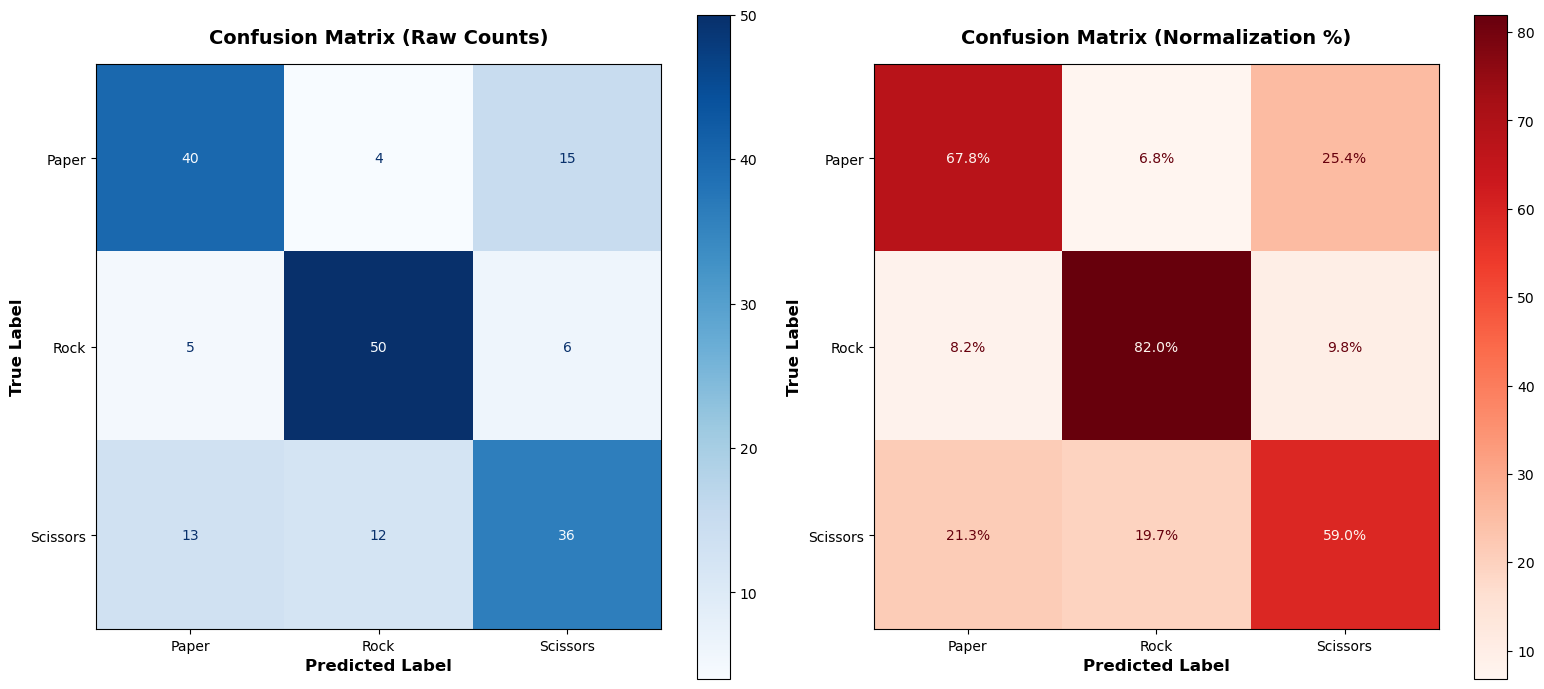


 📋 VALIDATION SET CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Paper       0.69      0.68      0.68        59
        Rock       0.76      0.82      0.79        61
    Scissors       0.63      0.59      0.61        61

    accuracy                           0.70       181
   macro avg       0.69      0.70      0.69       181
weighted avg       0.69      0.70      0.69       181


 📈 PER-CLASS ACCURACY ANALYSIS
🟡 Paper     :  67.8% Accuracy
🟢 Rock      :  82.0% Accuracy
🔴 Scissors  :  59.0% Accuracy


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# ==========================================
# 1. GENERATING PREDICTIONS (Saktësuar)
# ==========================================
print("Generating predictions for the validation set...")

# SHËNIM: Sigurohemi që të dhënat të mos jenë të përziera (no shuffle) 
# gjatë nxjerrjes së y_true që të përputhen me predict()
y_true = []
y_pred_probs = []

# Iterojmë nëpër validation set
for images, labels in val_ds:
    # 1. Ruajmë labels origjinale (y_true)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    
    # 2. bëjmë parashikimin për këtë batch
    preds = model.predict(images, verbose=0)
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
pred_classes = np.argmax(np.array(y_pred_probs), axis=1)

# Emrat e klasave
class_names = ['Paper', 'Rock', 'Scissors']

# ==========================================
# 2. CREATING THE CONFUSION MATRIX
# ==========================================
cm = confusion_matrix(y_true, pred_classes)

# ==========================================
# 3. VISUALIZATION (Counts and Percentages)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Plot 1: Raw Counts ---
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp1.plot(cmap='Blues', ax=axes[0], colorbar=True, values_format='d')
axes[0].set_title('Confusion Matrix (Raw Counts)', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12, fontweight='bold')
axes[0].grid(False)

# --- Plot 2: Normalized Percentages ---
# Normalize by row (True Labels)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=class_names)
disp2.plot(cmap='Reds', ax=axes[1], colorbar=True, values_format='.1f')
axes[1].set_title('Confusion Matrix (Normalization %)', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12, fontweight='bold')
axes[1].grid(False)

# Shtohet shenja % në tekstin e kutive
for text in disp2.text_.ravel():
    text.set_text(text.get_text() + '%')

plt.tight_layout()
plt.show()

# ==========================================
# 4. VALIDATION SET CLASSIFICATION REPORT
# ==========================================
print("\n" + "="*60)
print(" 📋 VALIDATION SET CLASSIFICATION REPORT")
print("="*60)
# Gjenerojmë raportin
report = classification_report(y_true, pred_classes, target_names=class_names)
print(report)
print("="*60)

# ==========================================
# 5. QUICK CONSOLE ANALYSIS
# ==========================================
print("\n" + "="*45)
print(" 📈 PER-CLASS ACCURACY ANALYSIS")
print("="*45)

for i, class_name in enumerate(class_names):
    accuracy = cm_normalized[i, i]
    # Status indicator bazuar në saktësinë
    emoji = "🟢" if accuracy >= 80 else "🟡" if accuracy >= 60 else "🔴"
    print(f"{emoji} {class_name:10s}: {accuracy:5.1f}% Accuracy")

print("="*45)

🤖 Model is thinking... predicting validation samples...


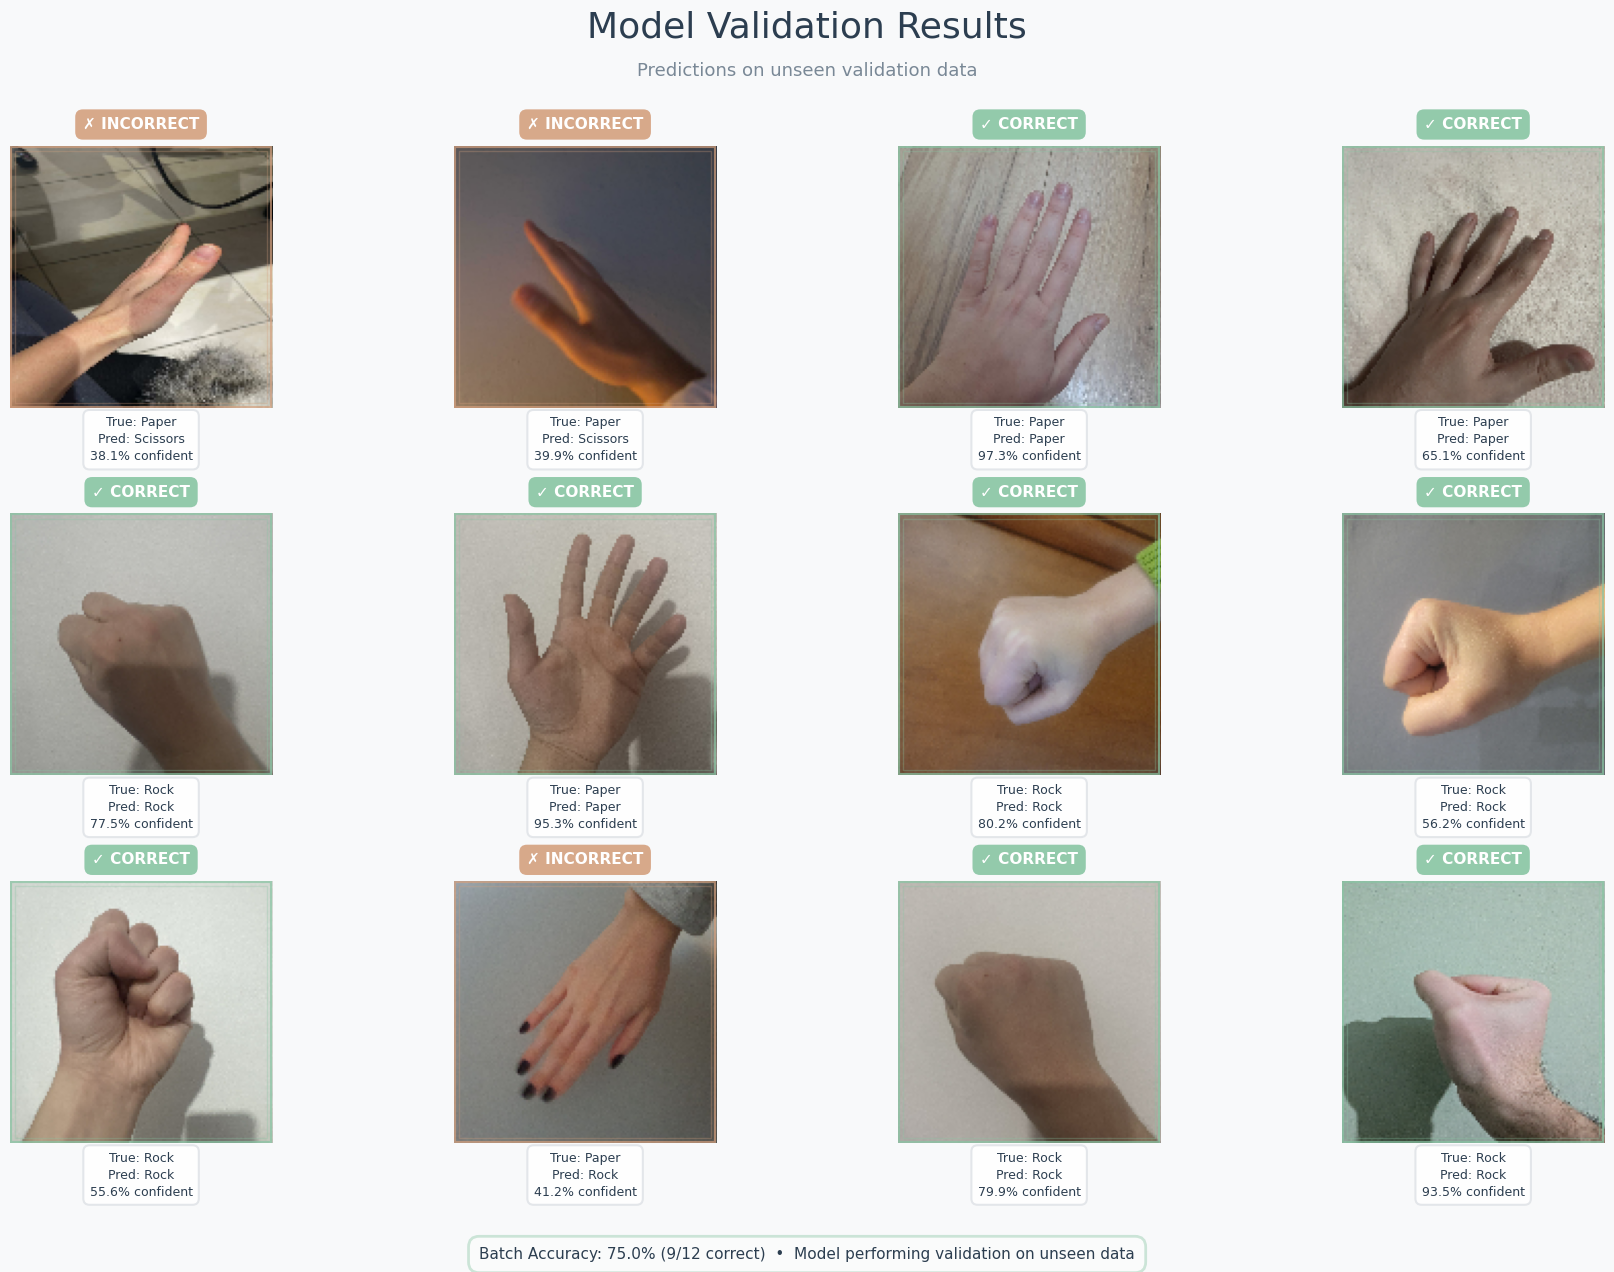

✓ Validation complete! Accuracy: 75.0%


In [7]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from matplotlib.patches import Rectangle, FancyBboxPatch

# ==========================================
# 1. GET DATA FROM VALIDATION SET
# ==========================================
test_samples = val_ds.unbatch().shuffle(100).batch(12)
images, labels = next(iter(test_samples))

# ==========================================
# 2. RUN MODEL PREDICTIONS
# ==========================================
print("🤖 Model is thinking... predicting validation samples...")
predictions = model.predict(images, verbose=0)

class_names = ['Paper', 'Rock', 'Scissors']

# ==========================================
# 3. MODERN VALIDATION VISUALIZATION
# ==========================================

# Soft professional colors
COLORS = {
    'bg': '#f8f9fa',
    'correct': '#88c5a3',      # Soft green
    'incorrect': '#d4a07e',    # Soft coral/orange (not harsh red)
    'text_dark': '#2c3e50',
    'text_light': '#5a6c7d',
    'border_light': '#e1e4e8'
}

fig = plt.figure(figsize=(18, 13), facecolor=COLORS['bg'])

# Modern header
fig.text(0.5, 0.96, "Model Validation Results", 
         ha='center', fontsize=26, fontweight='500', color=COLORS['text_dark'])

fig.text(0.5, 0.93, "Predictions on unseen validation data", 
         ha='center', fontsize=13, color=COLORS['text_light'], alpha=0.8)

# Calculate accuracy for this batch
correct_predictions = sum([1 for i in range(len(images)) 
                          if np.argmax(labels[i]) == np.argmax(predictions[i])])
batch_accuracy = (correct_predictions / len(images)) * 100

for i in range(len(images)):
    ax = plt.subplot(3, 4, i + 1)
    
    # Process image for display
    display_img = images[i].numpy()
    if np.max(display_img) <= 1.1:
        display_img = (display_img * 255).astype("uint8")
    else:
        display_img = display_img.astype("uint8")
    
    plt.imshow(display_img)
    
    # Extract labels and predictions
    actual_idx = np.argmax(labels[i]) if len(labels[i].shape) > 0 else int(labels[i])
    pred_idx = np.argmax(predictions[i])
    confidence = 100 * np.max(predictions[i])
    
    # Determine if correct
    is_correct = (actual_idx == pred_idx)
    theme_color = COLORS['correct'] if is_correct else COLORS['incorrect']
    status_icon = '✓' if is_correct else '✗'
    status_text = 'CORRECT' if is_correct else 'INCORRECT'
    
    # Clean title with status
    title_text = f"{status_icon} {status_text}"
    plt.title(title_text, 
             color='white', 
             fontsize=11, 
             fontweight='600',
             pad=12,
             bbox=dict(boxstyle='round,pad=0.5', 
                      facecolor=theme_color, 
                      edgecolor='none',
                      alpha=0.9))
    
    plt.axis("off")
    
    # Soft border
    border = Rectangle((0, 0), 1, 1, 
                      fill=False, 
                      color=theme_color, 
                      lw=3, 
                      transform=ax.transAxes,
                      alpha=0.7)
    ax.add_patch(border)
    
    # Inner subtle border
    inner_border = Rectangle((0.02, 0.02), 0.96, 0.96, 
                            fill=False, 
                            color=theme_color, 
                            lw=1, 
                            transform=ax.transAxes,
                            alpha=0.3)
    ax.add_patch(inner_border)
    
    # Info text at bottom
    info_text = (f"True: {class_names[actual_idx]}\n"
                f"Pred: {class_names[pred_idx]}\n"
                f"{confidence:.1f}% confident")
    
    ax.text(0.5, -0.2, info_text, 
           transform=ax.transAxes,
           ha='center',
           fontsize=9,
           color=COLORS['text_dark'],
           linespacing=1.4,
           bbox=dict(boxstyle='round,pad=0.5', 
                    facecolor='white', 
                    edgecolor=COLORS['border_light'],
                    linewidth=1.5,
                    alpha=0.9))

# Summary footer
footer_text = f"Batch Accuracy: {batch_accuracy:.1f}% ({correct_predictions}/{len(images)} correct)  •  Model performing validation on unseen data"

fig.text(0.5, 0.02, footer_text, 
        ha='center', fontsize=11, color=COLORS['text_dark'],
        bbox=dict(boxstyle='round,pad=0.7', 
                 facecolor='white', 
                 edgecolor=COLORS['correct'],
                 linewidth=2,
                 alpha=0.4))

plt.tight_layout(rect=[0, 0.05, 1, 0.91])
plt.savefig('validation_results_modern.png', dpi=150, facecolor=COLORS['bg'], bbox_inches='tight')
plt.show()

print(f"✓ Validation complete! Accuracy: {batch_accuracy:.1f}%")

In [8]:
# Ruaj modelin
model.save('CNN_model5.keras')
print("✅ Model Save")

✅ Model Save
